In [2]:
import pandas as pd

df = pd.read_csv("Analytica.csv") 

print("shape:", df.shape)
print("\ncolumns:", df.columns.tolist()[:30], "...")

print("\nTarget value counts (incl NaN):")
print(df["target"].value_counts(dropna=False))

print("\nTarget missing rate:")
print(df["target"].isna().mean())


shape: (34163, 112)

columns: ['EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9', 'EXT10', 'EST1', 'EST2', 'EST3', 'EST4', 'EST5', 'EST6', 'EST7', 'EST8', 'EST9', 'EST10', 'AGR1', 'AGR2', 'AGR3', 'AGR4', 'AGR5', 'AGR6', 'AGR7', 'AGR8', 'AGR9', 'AGR10'] ...

Target value counts (incl NaN):
target
NaN    29067
0.0     2683
1.0     2413
Name: count, dtype: int64

Target missing rate:
0.8508327722975149


In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

print("\nMissing %:")
print((missing / len(df) * 100).round(2))


Columns with missing values:
target    29067
dtype: int64

Missing %:
target    85.08
dtype: float64


In [4]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["target", "ID"])
y = df["target"]

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [5]:
# from sklearn.decomposition import PCA

# model_pca = PCA(n_components=10)
# model_pca.fit(X)
# X_pca = model_pca.transform(X)
# ratio = model_pca.explained_variance_ratio_.sum()
# print(f"We explained {100*ratio:.2f}% of the global variance.")


In [6]:
# from sklearn.cluster import KMeans

# model = KMeans(n_clusters=20)
# model.fit(X_pca)
# cluster = model.predict(X_pca)


In [7]:
# from sklearn.metrics import silhouette_score

# score = silhouette_score(X_pca, labels=cluster)
# print(f"Silhouette score: {score:.4f}")


In [8]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


n_clusters = 5
components = range(20, 55)  

results = []

for n_components in components:
    pca = PCA(n_components=n_components, random_state=42)
    Xpca = pca.fit_transform(X)

    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = km.fit_predict(Xpca)

    sil = silhouette_score(Xpca, labels)
    evr = pca.explained_variance_ratio_.sum()

    results.append({
        "n_components": n_components,
        "explained_variance": evr,
        "silhouette": sil,
        "inertia": km.inertia_,
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("silhouette", ascending=False)
best_row = results_df.iloc[0]
best_n = int(best_row.n_components)

print("Best PCA n_components (by silhouette):", best_n)
print(best_row)

pca = PCA(n_components=best_n, random_state=42).fit(X)
X_pca = pca.transform(X)
km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(X_pca)



Best PCA n_components (by silhouette): 20
n_components          2.000000e+01
explained_variance    5.024536e-01
silhouette            7.721454e-02
inertia               1.357931e+06
Name: 0, dtype: float64


In [9]:
from sklearn.decomposition import PCA

model_pca = PCA(n_components=best_n)
model_pca.fit(X)
X_pca = model_pca.transform(X)
ratio = model_pca.explained_variance_ratio_.sum()
print(f"We explained {100*ratio:.2f}% of the global variance.")
from sklearn.cluster import KMeans

model = KMeans(n_clusters=5)
model.fit(X_pca)
cluster = model.predict(X_pca)
from sklearn.metrics import silhouette_score

score = silhouette_score(X_pca, labels=cluster)
print(f"Silhouette score: {score:.4f}")


We explained 50.25% of the global variance.
Silhouette score: 0.0777


/var/folders/k9/89sz9rmn25s78pr1yz7ytdz40000gn/T/ipykernel_6281/2830197515.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


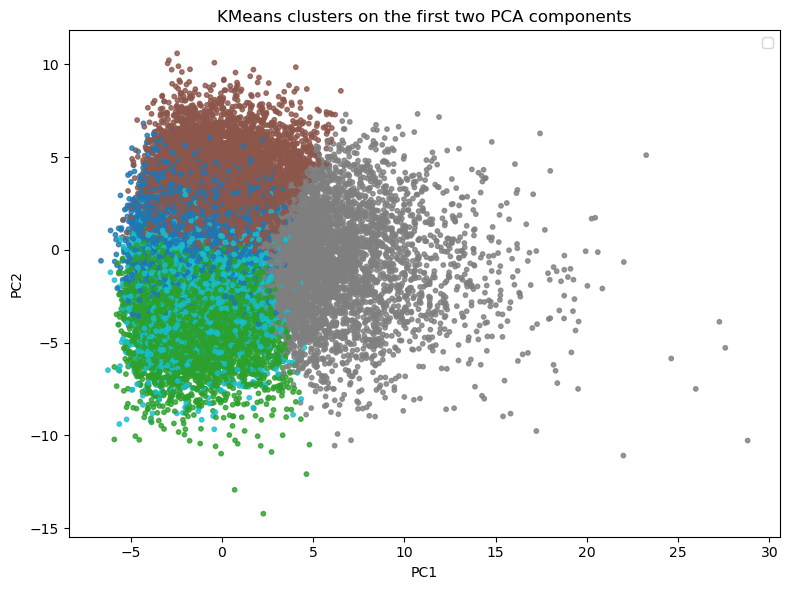

In [10]:
import numpy as np
import matplotlib.pyplot as plt

cluster = cluster.astype(int)  # safety

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    Xpca[:, 0], Xpca[:, 1],
    c=cluster,              
    s=10,
    alpha=0.8,
    cmap="tab10"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters on the first two PCA components")


plt.legend()
plt.tight_layout()
plt.show()


In [11]:
import numpy as np
print("Unique labels:", np.unique(cluster))
print("Counts:", np.bincount(cluster.astype(int)))


Unique labels: [0 1 2 3 4]
Counts: [7204 7611 8765 4851 5732]


In [12]:
df['cluster'] = cluster
df['cluster'] = cluster.astype(int)
df.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,EST,EST_time,AGR,AGR_time,CSN,CSN_time,OPN,OPN_time,target,cluster
0,3.0,2.0,2.0,4.0,4.0,4.0,5.0,3.0,1.0,3.0,...,0.44,46.155,0.24,82.665,0.10,62.022,0.10,40.415,NaN,1
1,3.0,4.0,1.0,4.0,3.0,2.0,2.0,4.0,3.0,5.0,...,0.42,36.420,-0.14,86.422,0.10,56.401,0.26,38.205,0.0,4
2,3.0,3.0,4.0,4.0,5.0,3.0,3.0,5.0,2.0,2.0,...,0.42,50.268,0.50,58.487,0.18,44.737,0.34,51.454,NaN,0
3,1.0,5.0,1.0,5.0,2.0,4.0,1.0,5.0,3.0,5.0,...,0.64,59.489,0.22,59.080,0.18,66.815,0.32,58.911,NaN,1
4,1.0,4.0,3.0,5.0,1.0,2.0,2.0,4.0,2.0,4.0,...,0.46,39.848,0.40,97.554,0.24,45.858,0.42,48.390,0.0,1


In [13]:
features = df.columns.drop(['ID', 'target', 'cluster'], errors='ignore')

cluster_sizes = df['cluster'].value_counts().sort_index()
cluster_means = df.groupby('cluster')[features].mean()
cluster_medians = df.groupby('cluster')[features].median()
global_mean = df[features].mean()
delta = cluster_means - global_mean
top_pos = delta.apply(lambda s: s.nlargest(5).index.tolist(), axis=1)
top_neg = delta.apply(lambda s: s.nsmallest(5).index.tolist(), axis=1)



In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


features = df.columns.drop(['ID', 'target', 'cluster'], errors='ignore')
assert 'cluster' in df.columns, "df must contain a 'cluster' column"

cluster_sizes  = df['cluster'].value_counts().sort_index()
cluster_means  = df.groupby('cluster')[features].mean(numeric_only=True)
global_mean    = df[features].mean(numeric_only=True)
delta          = cluster_means.subtract(global_mean, axis=1)

top_pos = delta.apply(lambda s: s.nlargest(5).index.tolist(), axis=1)
top_neg = delta.apply(lambda s: s.nsmallest(5).index.tolist(), axis=1)

summary = pd.DataFrame({
    "cluster_size": cluster_sizes,
    "top_pos(5)": top_pos,
    "top_neg(5)": top_neg,
})

display(summary.style.set_properties(**{"white-space": "pre-wrap"}))


,cluster_size,top_pos(5),top_neg(5)
cluster,,,
0,7204,"['EXT7', 'EXT9', 'CSN2', 'CSN6', 'EXT1']","['AGR1_E', 'EST4_E', 'OPN2_E', 'CSN10_E', 'OPN4_E']"
1,7611,"['EST1', 'EXT10', 'EST10', 'EST6', 'EST8']","['EXT1_E', 'EXT4_E', 'EST4_E', 'EXT8_E', 'EXT10_E']"
2,8765,"['EXT10_E', 'EXT8_E', 'EXT3', 'CSN5', 'EXT5']","['AGR1_E', 'CSN8_E', 'AGR3_E', 'OPN2_E', 'AGR4_E']"
3,4851,"['EXT1_E', 'CSN8_E', 'EST4_E', 'OPN2_E', 'AGR1_E']","['OPN8', 'OPN1', 'OPN7', 'EXT8', 'EST10']"
4,5732,"['AGR5', 'AGR7', 'AGR1', 'EXT2', 'EXT10']","['EXT1_E', 'CSN8_E', 'CSN10_E', 'OPN2_E', 'EXT4_E']"


### Put it all together:

In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def run_pipeline(df, n_components = 20, n_clusters = 5, random_state=42):
    X = df.drop(columns=["target", "ID"])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=n_components, random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)

    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = km.fit_predict(X_pca)

    return {
        "n_components": n_components,
        "n_clusters": n_clusters,
        "explained_variance": pca.explained_variance_ratio_.sum(),
        "silhouette": silhouette_score(X_pca, labels),
        "inertia": km.inertia_,
    }


In [16]:
metrics = run_pipeline(df)

print(metrics)

{'n_components': 20, 'n_clusters': 5, 'explained_variance': np.float64(0.5028084754862034), 'silhouette': 0.08769432370170868, 'inertia': 1348824.7847340328}


Components for 90% variance: 15
Components for 95% variance: 18


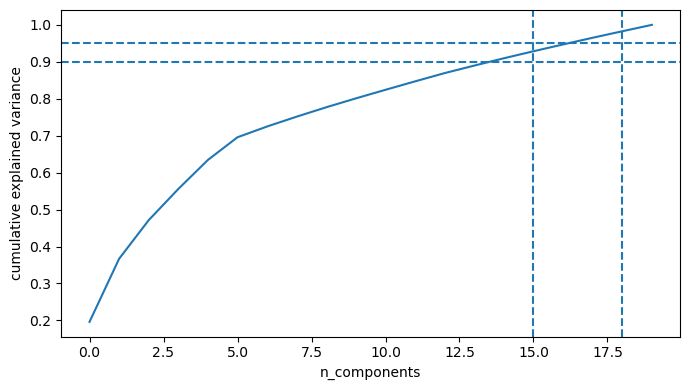

Using best_n = 18


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = X_pca
pca_full = PCA().fit(X)
cum = np.cumsum(pca_full.explained_variance_ratio_)

best_n_90 = int(np.argmax(cum >= 0.90) + 1)
best_n_95 = int(np.argmax(cum >= 0.95) + 1)

print("Components for 90% variance:", best_n_90)
print("Components for 95% variance:", best_n_95)

plt.figure(figsize=(7,4))
plt.plot(cum)
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.axvline(best_n_90, linestyle="--")
plt.axvline(best_n_95, linestyle="--")
plt.xlabel("n_components")
plt.ylabel("cumulative explained variance")
plt.tight_layout()
plt.show()

best_n = best_n_95
print("Using best_n =", best_n)


In [18]:
from sklearn.decomposition import PCA
import numpy as np

best_n = 18  

pca = PCA(n_components=best_n)
X_pca = pca.fit_transform(X)

print("X_pca shape:", X_pca.shape)
print("Explained variance (sum):", np.sum(pca.explained_variance_ratio_))


X_pca shape: (34163, 18)
Explained variance (sum): 0.9650799262541939


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop(columns=["target", "ID"])   
X_scaled = StandardScaler().fit_transform(X)

pca_full = PCA().fit(X_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)

best_n_90 = int(np.argmax(cum >= 0.90) + 1)
best_n_95 = int(np.argmax(cum >= 0.95) + 1)

print("Components for 90% variance:", best_n_90)
print("Components for 95% variance:", best_n_95)


Components for 90% variance: 76
Components for 95% variance: 87


In [20]:
known = df["target"].notna()
cluster_mu = df.loc[known].groupby("cluster")["target"].mean()
global_mu = df.loc[known, "target"].mean()

df["target_prob_cluster"] = df["cluster"].map(cluster_mu).fillna(global_mu)
df["target_pred_cluster"] = (df["target_prob_cluster"] > 0.5).astype(int)

missing = ~known
print("Labeled rows:", int(known.sum()))
print("Unlabeled rows:", int(missing.sum()))
print("\nCluster target means (labeled only):")
print(cluster_mu.sort_index())

print("\nPredicted positive rate on unlabeled:", float(df.loc[missing, "target_pred_cluster"].mean()))


Labeled rows: 5096
Unlabeled rows: 29067

Cluster target means (labeled only):
cluster
0    0.254044
1    0.383054
2    0.708108
3    0.520639
4    0.466513
Name: target, dtype: float64

Predicted positive rate on unlabeled: 0.39804589396910584


In [21]:
unlabeled = df["target"].isna()

submit = df.loc[unlabeled, ["ID"]].copy()
submit["target"] = df.loc[unlabeled, "target_pred_cluster"].astype(int)

print("submit shape:", submit.shape)
print(submit["target"].value_counts())

submit.to_csv("submit_cluster.csv", index=False)
submit.head()


submit shape: (29067, 2)
target
0    17497
1    11570
Name: count, dtype: int64


,ID,target
0,20160303022202,0
2,20160303052049,0
3,20160303052319,0
5,20160303055318,1
6,20160303063505,0


In [22]:
known = df["target"].notna()
df_lab = df.loc[known].copy()

y = df_lab["target"].astype(int)

X = df_lab.drop(columns=["target", "ID"], errors="ignore")
X = X.drop(columns=["cluster"], errors="ignore")  # we can add it back later as an experiment

print("Labeled X shape:", X.shape)
print("Labeled y shape:", y.shape)
print("Class balance (y mean):", float(y.mean()))
print(y.value_counts())


Labeled X shape: (5096, 112)
Labeled y shape: (5096,)
Class balance (y mean): 0.47350863422291994
target
0    2683
1    2413
Name: count, dtype: int64


In [23]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

aucs, accs = [], []

for tr, te in skf.split(X, y):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]

    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_tr, y_tr)

    p = rf.predict_proba(X_te)[:, 1]
    pred = (p >= 0.5).astype(int)

    aucs.append(roc_auc_score(y_te, p))
    accs.append(accuracy_score(y_te, pred))

print("RF AUC:     ", float(np.mean(aucs)), "±", float(np.std(aucs)))
print("RF Accuracy:", float(np.mean(accs)), "±", float(np.std(accs)))


RF AUC:      0.8745292138401004 ± 0.007167281165354479
RF Accuracy: 0.7896392079893783 ± 0.011211157374642627


In [24]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

known = df["target"].notna()
df_lab = df.loc[known].copy()
y = df_lab["target"].astype(int)

X_raw = df_lab.drop(columns=["target", "ID"], errors="ignore").copy()
X_raw_no_cluster = X_raw.drop(columns=["cluster"], errors="ignore")

X_raw_with_cluster = X_raw.copy()
if "cluster" in X_raw_with_cluster.columns:
    X_raw_with_cluster["cluster"] = X_raw_with_cluster["cluster"].astype(int)

def cv_auc(X_df):
    aucs = []
    for tr, te in skf.split(X_df, y):
        X_tr, X_te = X_df.iloc[tr], X_df.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        rf = RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        )
        rf.fit(X_tr, y_tr)
        p = rf.predict_proba(X_te)[:, 1]
        aucs.append(roc_auc_score(y_te, p))
    return float(np.mean(aucs)), float(np.std(aucs))

m1 = cv_auc(X_raw_no_cluster)

scaler = StandardScaler()
Xp = scaler.fit_transform(X_raw_no_cluster)
Xp = PCA(n_components=18, random_state=42).fit_transform(Xp)
Xp = pd.DataFrame(Xp, index=X_raw_no_cluster.index)

m2 = cv_auc(Xp)
m3 = cv_auc(X_raw_with_cluster)

print("Raw features (no cluster):      AUC =", m1[0], "±", m1[1])
print("PCA(18) features:              AUC =", m2[0], "±", m2[1])
print("Raw features + cluster feature: AUC =", m3[0], "±", m3[1])


Raw features (no cluster):      AUC = 0.8745292138401004 ± 0.007167281165354479
PCA(18) features:              AUC = 0.8570409643238419 ± 0.009287093766538149
Raw features + cluster feature: AUC = 0.8742951391976458 ± 0.0073222507679875665


In [25]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

known = df["target"].notna()
df_lab = df.loc[known].copy()
df_unlab = df.loc[~known].copy()

X_train = df_lab.drop(columns=["target", "ID", "cluster"], errors="ignore")
y_train = df_lab["target"].astype(int)

X_test = df_unlab.drop(columns=["target", "ID", "cluster"], errors="ignore")

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

df.loc[~known, "target_prob_rf"] = proba
df.loc[~known, "target_pred_rf"] = pred

submit = df_unlab[["ID"]].copy()
submit["target"] = pred
submit.to_csv("submit_rf.csv", index=False)

print("submit_rf shape:", submit.shape)
print(submit["target"].value_counts())
submit.head()


submit_rf shape: (29067, 2)
target
0    15824
1    13243
Name: count, dtype: int64


,ID,target
0,20160303022202,1
2,20160303052049,1
3,20160303052319,0
5,20160303055318,1
6,20160303063505,1


In [26]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

known = df["target"].notna()
df_lab = df.loc[known].copy()

X_train = df_lab.drop(columns=["target", "ID", "cluster"], errors="ignore")
y_train = df_lab["target"].astype(int)

rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
display(imp.head(25))


OPN                    0.082632
CSN                    0.077931
EST                    0.039306
CSN6                   0.026081
CSN4                   0.024865
CSN2                   0.022677
target_prob_cluster    0.021544
CSN5                   0.020026
OPN3                   0.016513
EST10                  0.015532
EXT                    0.015394
OPN8                   0.014124
target_pred_cluster    0.013084
OPN1                   0.011764
CSN9                   0.011601
EST8                   0.009917
AGR                    0.009708
OPN10                  0.009247
EST1                   0.009112
EXT_time               0.008972
EXT3                   0.008514
OPN4                   0.008435
EST9                   0.008288
AGR4_E                 0.008013
EST4_E                 0.007915
dtype: float64

In [27]:
unl = df["target"].isna()

cases_01 = df.loc[unl & (df["target_pred_cluster"] == 0)].copy()
cases_01 = cases_01.sort_values("target_prob_rf", ascending=False).head(20)

cases_10 = df.loc[unl & (df["target_pred_cluster"] == 1)].copy()
cases_10 = cases_10.sort_values("target_prob_rf", ascending=True).head(20)

cols = ["ID", "cluster", "target_prob_cluster", "target_pred_cluster", "target_prob_rf", "target_pred_rf", "OPN", "CSN", "EST", "EXT", "AGR"]
cols = [c for c in cols if c in df.columns]

print("Cluster=0 but RF high (top 20):")
display(cases_01[cols])

print("Cluster=1 but RF low (top 20):")
display(cases_10[cols])


Cluster=0 but RF high (top 20):


,ID,cluster,target_prob_cluster,target_pred_cluster,target_prob_rf,target_pred_rf,OPN,CSN,EST,EXT,AGR
33714,20181101173640,4,0.466513,0,0.949813,1.0,0.10,0.32,0.14,0.06,0.20
16311,20170821104659,1,0.383054,0,0.934225,1.0,0.14,0.34,0.32,-0.04,0.26
23658,20180401190916,4,0.466513,0,0.933043,1.0,0.22,0.44,0.24,-0.24,0.16
26542,20180603175437,4,0.466513,0,0.929830,1.0,0.30,0.36,0.16,-0.02,0.10
18170,20171031153254,4,0.466513,0,0.928599,1.0,0.14,0.24,0.20,-0.06,0.22
12865,20170317055619,4,0.466513,0,0.927136,1.0,0.24,0.26,0.20,0.02,0.24
29959,20180827203707,4,0.466513,0,0.926954,1.0,0.28,0.36,0.10,-0.14,0.24
14785,20170602111014,4,0.466513,0,0.923094,1.0,0.20,0.32,0.16,-0.02,0.18
8540,20161025133048,4,0.466513,0,0.920662,1.0,0.30,0.46,0.20,-0.18,0.14
26746,20180609063958,1,0.383054,0,0.917844,1.0,0.20,0.42,0.34,-0.04,0.26


Cluster=1 but RF low (top 20):


,ID,cluster,target_prob_cluster,target_pred_cluster,target_prob_rf,target_pred_rf,OPN,CSN,EST,EXT,AGR
13020,20170322170814,3,0.520639,1,0.087115,0.0,0.56,-0.06,0.58,-0.14,0.50
14216,20170503080435,3,0.520639,1,0.097898,0.0,0.56,-0.04,0.46,-0.04,0.40
32456,20181010103601,3,0.520639,1,0.101084,0.0,0.62,0.00,0.60,-0.32,0.02
32522,20181011163203,3,0.520639,1,0.103495,0.0,0.60,0.00,0.72,-0.26,0.12
12113,20170225032821,3,0.520639,1,0.106028,0.0,0.56,0.04,0.56,-0.24,0.26
21375,20180219095420,3,0.520639,1,0.106517,0.0,0.56,0.10,0.44,-0.22,0.08
29834,20180825060227,3,0.520639,1,0.115791,0.0,0.44,-0.06,0.66,-0.36,0.36
10777,20170123103431,3,0.520639,1,0.116931,0.0,0.62,-0.02,0.54,-0.12,0.30
26883,20180612172818,3,0.520639,1,0.118066,0.0,0.50,-0.02,0.42,-0.20,0.44
24661,20180420184412,3,0.520639,1,0.119865,0.0,0.42,0.06,0.62,-0.32,0.02


In [28]:
unl = df["target"].isna()

tmp = df.loc[unl, ["cluster", "target_prob_cluster", "target_pred_cluster", "target_prob_rf", "target_pred_rf"]].copy()
tmp["disagree"] = (tmp["target_pred_cluster"] != tmp["target_pred_rf"]).astype(int)

summary = tmp.groupby("cluster").agg(
    n=("disagree", "size"),
    disagree_rate=("disagree", "mean"),
    cluster_prob=("target_prob_cluster", "mean"),
    rf_prob_mean=("target_prob_rf", "mean"),
    rf_prob_median=("target_prob_rf", "median"),
    pct_cluster_pred1=("target_pred_cluster", "mean"),
    pct_rf_pred1=("target_pred_rf", "mean"),
).sort_values("disagree_rate", ascending=False)

display(summary)


,n,disagree_rate,cluster_prob,rf_prob_mean,rf_prob_median,pct_cluster_pred1,pct_rf_pred1
cluster,,,,,,,
3,4100,0.466585,0.520639,0.526159,0.522222,1.0,0.533415
4,4866,0.391081,0.466513,0.455767,0.436375,0.0,0.391081
1,6478,0.321395,0.383054,0.391211,0.355115,0.0,0.321395
2,7470,0.155957,0.708108,0.664905,0.656866,1.0,0.844043
0,6153,0.124492,0.254044,0.291348,0.259871,0.0,0.124492


In [29]:
focus = 3
unl = df["target"].isna()

sub = df.loc[unl & (df["cluster"] == focus)].copy()
sub["rf_group"] = sub["target_pred_rf"].map({0: "RF=0", 1: "RF=1"})

cols = ["OPN", "CSN", "EST", "EXT", "AGR", "OPN_time", "CSN_time", "EST_time", "EXT_time", "AGR_time"]
cols = [c for c in cols if c in sub.columns]

g = sub.groupby("rf_group")[cols].mean(numeric_only=True)
display(g)

print("Counts:")
print(sub["rf_group"].value_counts())


,OPN,CSN,EST,EXT,AGR,OPN_time,CSN_time,EST_time,EXT_time,AGR_time
rf_group,,,,,,,,,,
RF=0,0.438725,0.129974,0.402039,-0.021746,0.273717,87.644718,101.539951,90.533090,99.721252,95.182730
RF=1,0.335199,0.282405,0.286786,0.008660,0.286264,91.365163,99.595487,90.752689,101.911341,95.188432


Counts:
rf_group
RF=1    2187
RF=0    1913
Name: count, dtype: int64


In [30]:
import pandas as pd

unl = df["target"].isna()
traits = ["OPN","CSN","EST","EXT","AGR","OPN_time","CSN_time","EST_time","EXT_time","AGR_time"]
traits = [t for t in traits if t in df.columns]

rows = []
for c in sorted(df.loc[unl, "cluster"].unique()):
    sub = df.loc[unl & (df["cluster"] == c)].copy()
    if sub["target_pred_rf"].nunique() < 2:
        continue
    m = sub.groupby("target_pred_rf")[traits].mean(numeric_only=True)
    diff = (m.loc[1] - m.loc[0]).rename(lambda x: f"diff_{x}")
    rows.append(pd.concat([
        pd.Series({"cluster": c, "n": len(sub), "rf1_rate": sub["target_pred_rf"].mean()}),
        diff
    ]))

summary = pd.DataFrame(rows).set_index("cluster").sort_values("n", ascending=False)
display(summary)


,n,rf1_rate,diff_OPN,diff_CSN,diff_EST,diff_EXT,diff_AGR,diff_OPN_time,diff_CSN_time,diff_EST_time,diff_EXT_time,diff_AGR_time
cluster,,,,,,,,,,,,
2.0,7470.0,0.844043,-0.090808,0.099740,-0.040542,0.048297,-0.018467,6.796676,4.819530,2.876367,7.165890,5.608923
1.0,6478.0,0.321395,-0.107730,0.134831,-0.101029,0.051269,0.011889,1.518265,0.218061,1.972330,1.002940,0.248171
0.0,6153.0,0.124492,-0.175346,0.089384,-0.027373,0.053197,-0.013426,0.742568,-1.011438,-0.573422,-1.753813,-0.110061
4.0,4866.0,0.391081,-0.135513,0.111970,-0.073274,0.043787,0.014098,3.441205,1.743469,0.575032,3.159322,2.715403
3.0,4100.0,0.533415,-0.103526,0.152431,-0.115253,0.030406,0.012548,3.720446,-1.944464,0.219598,2.190089,0.005702
